## Emma Ugarcovici - Homework 4
### April 3, 2026

In [1]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(knitr, tidyverse, ggplot2, dplyr, lubridate, stringr, readxl, data.table, gdata, scales, broom, stargazer, rdrobust, fixest)

Loading required package: pacman



In [2]:
file_list <- list.files(path = "../data/output", pattern = "data-.*\\.csv", full.names = TRUE)

# Read all csvs 2009-2019 into one data frame
hwk.data <- file_list %>%
map_df(~read_csv(., col_types = cols(provider_number = col_character()))) %>%
  mutate(year = as.numeric(year)) %>%  
  filter(year >= 2009 & year <= 2019)

### Question 1: From 2009-2019, how many hospitals filed more than one report in the same year?

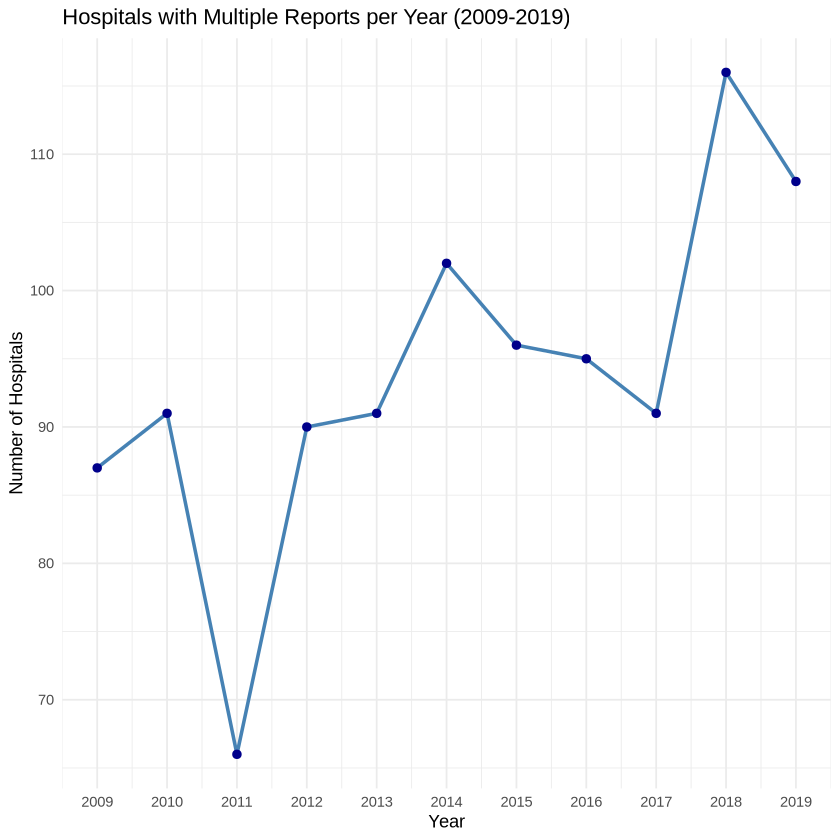

In [3]:
# Load raw data
final.hcris.v1996 <- read_tsv('../data/input/HCRIS_Data_v1996.txt', show_col_types = FALSE)
final.hcris.v2010 <- read_tsv('../data/input/HCRIS_Data_v2010.txt', show_col_types = FALSE)

# Remerge
final.hcris <- bind_rows(final.hcris.v1996, final.hcris.v2010)

# Create the missing column again
final.hcris <- final.hcris %>%
  mutate(fyear = year(mdy(fy_end))) %>% 
    # creates total report column
  add_count(provider_number, fyear, name="total_reports") 

# Analysis for q1
q1_data <- final.hcris %>%
  filter(fyear >= 2009 & fyear <= 2019) %>%
  group_by(fyear) %>%
  summarize(mult_report_hospitals = n_distinct(provider_number[total_reports > 1]))

# Create line graph
ggplot(q1_data, aes(x = fyear, y = mult_report_hospitals)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_point(color = "darkblue", size = 2) +
  scale_x_continuous(breaks = 2009:2019) +
  theme_minimal() +
  labs(
    title = "Hospitals with Multiple Reports per Year (2009-2019)",
    x = "Year",
    y = "Number of Hospitals",
  )

### Question 2: After removing/combining multiple reports, how many unique hospital IDs (Medicare provider numbers) exist in the data?

In [6]:
unique_hospitals <- n_distinct(hwk.data$provider_number)
cat("Total unique Medicare provider numbers in cleaned data:", unique_hospitals, "\n")

Total unique Medicare provider numbers in cleaned data: 6897 


### Question 3: From 2009-2019, what is the distribution of total charges (tot_charges in the data) in each year? 

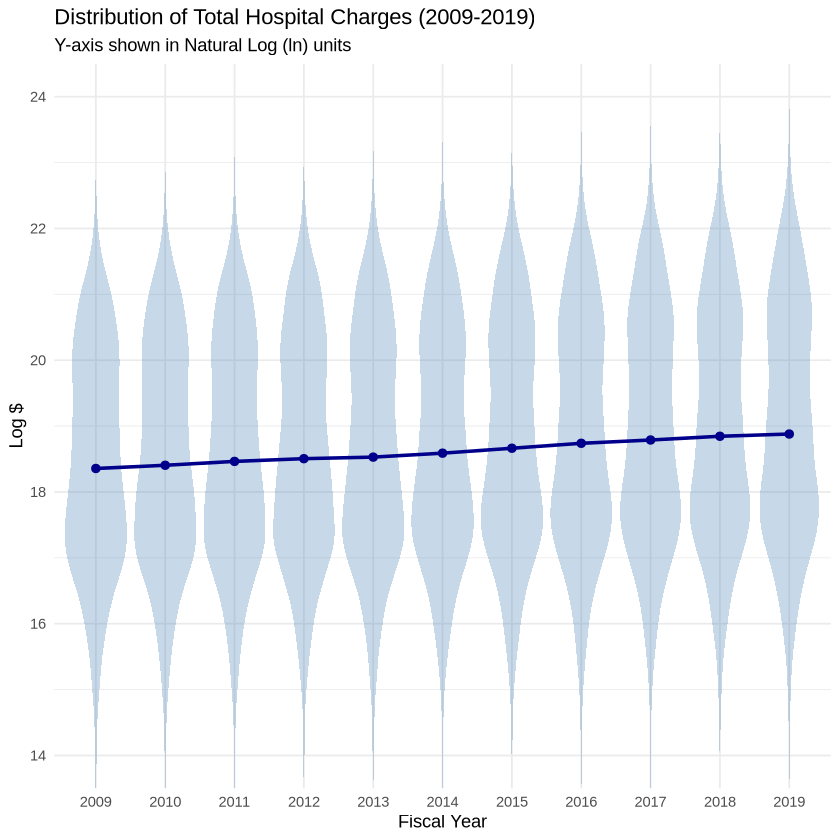

In [4]:
# Prep data
q3_plot_data <- hwk.data %>%
  filter(tot_charges > 0) %>%
  mutate(
    year_factor = as.factor(year),
    log_charges = log(tot_charges) # This creates the natural log (ln)
  )

# Create the plot
ggplot(q3_plot_data, aes(x = year_factor, y = log_charges)) +
geom_violin(fill = "steelblue", alpha = 0.3, color = NA) +
  
# Median points, trend line
stat_summary(fun = "median", geom = "point", color = "darkblue", size = 2) +
stat_summary(fun = "median", geom = "line", aes(group = 1), color = "darkblue", linewidth = 1) +

scale_y_continuous(breaks = seq(14, 24, 2)) + 
  
coord_cartesian(ylim = c(14, 24)) + 
  
theme_minimal() +
labs(
title = "Distribution of Total Hospital Charges (2009-2019)",
subtitle = "Y-axis shown in Natural Log (ln) units",
x = "Fiscal Year",
y = "Log $"
)

### Question 4: From 2009-2019, what is the distribution of estimated prices in each year?

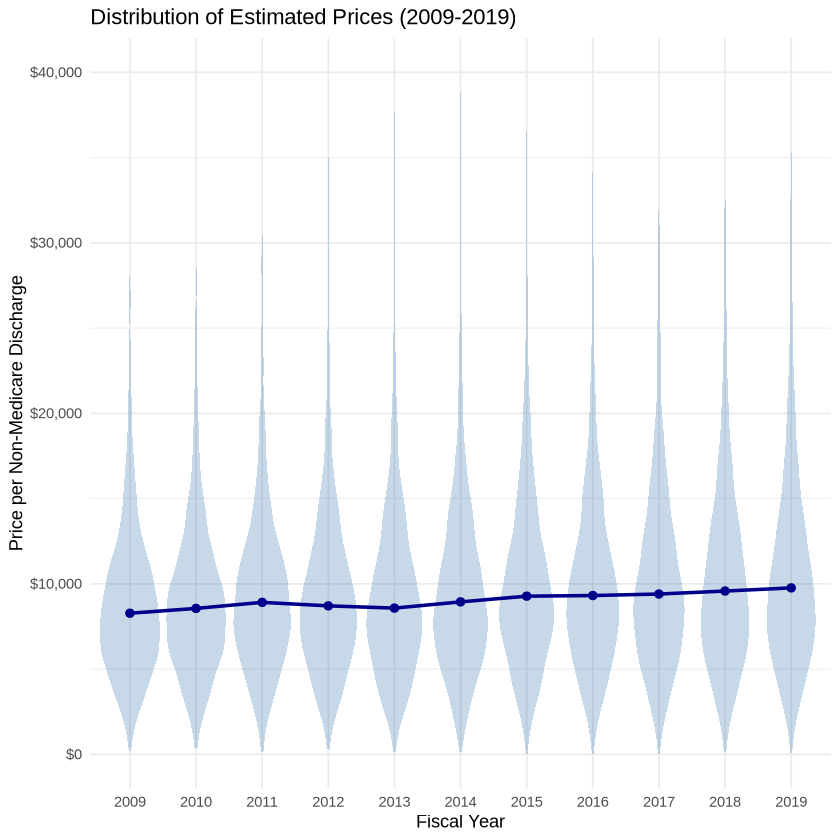

In [5]:
# Update main data frame with formulas
hwk.data <- hwk.data %>%
  mutate(
    discount_factor = 1 - (tot_discounts / tot_charges),
    discount_factor = ifelse(is.finite(discount_factor), discount_factor, 1),
    
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  )

# Filters + exclusion criteria
q4_plot_data <- hwk.data %>%
  filter(
    price_denom > 100, # Denominator > 100
    price_num >= 0, # No negative numerators
    price <= 100000, # Cap price at 100k
    price > 0, # Keep prices positive
    beds > 30 
  ) %>%
  mutate(year_factor = as.factor(year))

# Create the plot
ggplot(q4_plot_data, aes(x = year_factor, y = price)) +
geom_violin(fill = "steelblue", alpha = 0.3, color = NA) +
  
# Median points & trend line
stat_summary(fun = "median", geom = "point", color = "darkblue", size = 2) +
stat_summary(fun = "median", geom = "line", aes(group = 1), color = "darkblue", linewidth = 1) +
  
scale_y_continuous(labels = scales::label_dollar()) +
  
# Zoom in
coord_cartesian(ylim = c(0, 40000)) + 
  
theme_minimal() +
labs(
title = "Distribution of Estimated Prices (2009-2019)",
x = "Fiscal Year",
y = "Price per Non-Medicare Discharge"
)

### Question 5: What share of hospitals are penalized under the HRRP/VBP? (2012-2019)

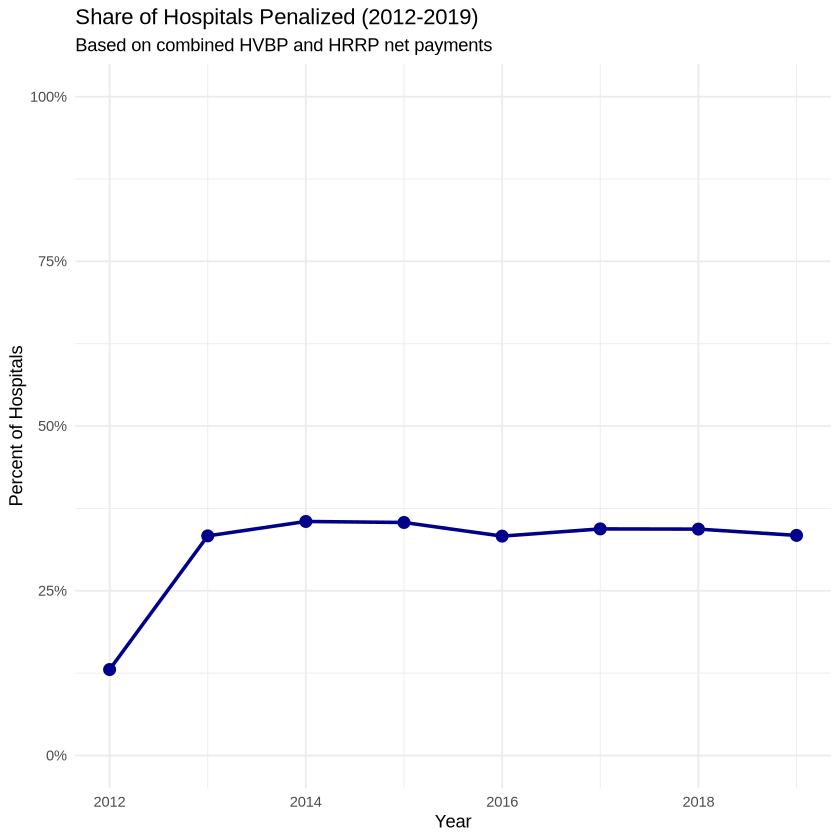

In [7]:
# Create penalty indicators
hwk.data <- hwk.data %>%
  mutate(
    hvbp_payment = ifelse(is.na(hvbp_payment), 0, hvbp_payment),
    hrrp_payment = ifelse(is.na(hrrp_payment), 0, abs(hrrp_payment)),
    
    # Calculate net penalty
    net_payment = hvbp_payment - hrrp_payment,
    
    # Binary indicator
    is_penalized = as.numeric(net_payment < 0)
    )

# Calculate share of penalized hospitals per year
q5_results <- hwk.data %>%
  filter(year >= 2012 & year <= 2019) %>%
  group_by(year) %>%
  summarize(
    total_hospitals = n(),
    penalized_count = sum(is_penalized, na.rm = TRUE),
    share_penalized = penalized_count / total_hospitals
  )

# Create plot
ggplot(q5_results, aes(x = year, y = share_penalized)) +
  geom_line(color = "darkblue", linewidth = 1) +
  geom_point(color = "darkblue", size = 3) +
  scale_y_continuous(labels = scales::percent, limits = c(0, 1)) +
  theme_minimal() +
  labs(
    title = "Share of Hospitals Penalized (2012-2019)",
    subtitle = "Based on combined HVBP and HRRP net payments",
    x = "Year",
    y = "Percent of Hospitals"
  )

### Question 6: Provide a summary of OLS estimates of the effect of net penalties on price changes.

In [8]:
iv_data <- hwk.data %>%
  filter(year >= 2009 & year <= 2014) %>%
  group_by(provider_number) %>%
  summarize(
    # Net payment from Q5
    penalty_amt = mean(net_payment[year == 2012], na.rm = TRUE),
    
    # Outcome: price change
    price_change = mean(price[year == 2014], na.rm = TRUE) - mean(price[year == 2011], na.rm = TRUE),
    
    # Instrument & Controls
    avg_mcare_disch = mean(mcare_discharges[year <= 2011], na.rm = TRUE),
    avg_beds = mean(beds[year <= 2011], na.rm = TRUE),
    avg_mcaid_disch = mean(mcaid_discharges[year <= 2011], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  # Clean
  filter(is.finite(price_change), 
         abs(price_change) < 50000, 
         avg_beds > 30)

# OLS
m1_ols <- feols(price_change ~ penalty_amt, data = iv_data)
m2_ols <- feols(price_change ~ penalty_amt + avg_beds, data = iv_data)
m3_ols <- feols(price_change ~ penalty_amt + avg_beds + avg_mcaid_disch, data = iv_data)

etable(m1_ols, m2_ols, m3_ols, tex = FALSE)

NOTE: 5 observations removed because of NA values (RHS: 5).

NOTE: 5 observations removed because of NA values (RHS: 5).

NOTE: 16 observations removed because of NA values (RHS: 16).



,,m1_ols,m2_ols,m3_ols
,<chr>,<chr>,<chr>,<chr>
1,Dependent Var.:,price_change,price_change,price_change
2,,,,
3,Constant,84.98 (75.02),66.95 (75.86),-65.01 (93.50)
4,penalty_amt,-0.0045* (0.0019),-0.0044* (0.0019),-0.0039* (0.0019)
5,avg_beds,,0.0751 (0.0476),0.0668 (0.0478)
6,avg_mcaid_disch,,,0.0842* (0.0350)
7,_______________,_________________,_________________,_________________
8,S.E. type,IID,IID,IID
9,Observations,"2,508","2,508","2,497"


### Question 7: Provide a scatterplot of net penalty against pre-2012 Medicare discharges.

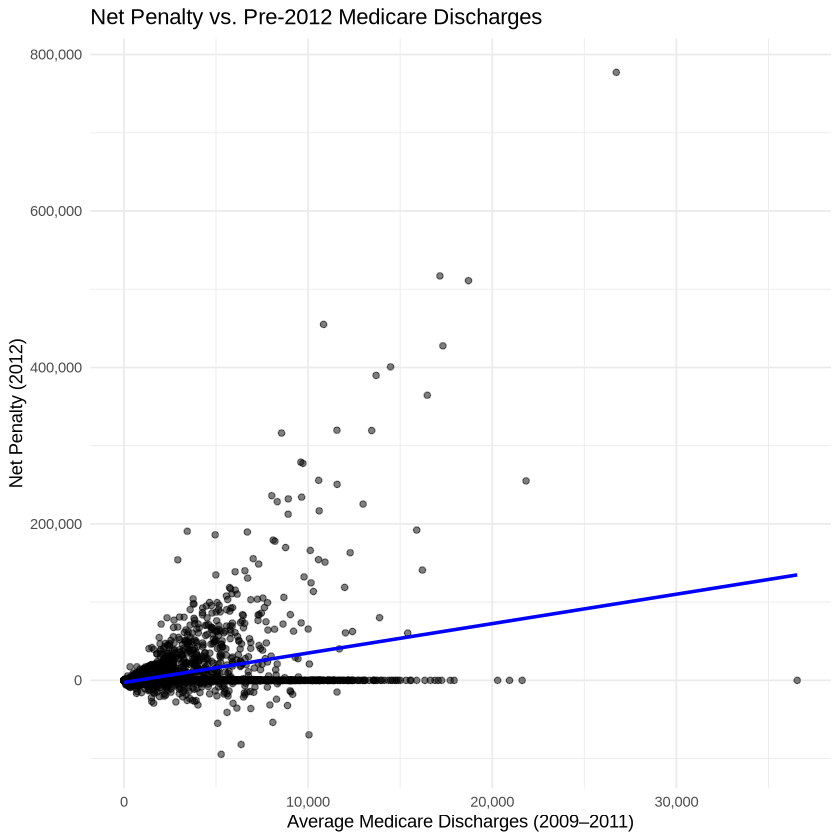

In [9]:
# Create dataset 
scatter_df <- hwk.data %>%
  mutate(
    hrrp_payment = if_else(is.na(hrrp_payment), 0, hrrp_payment),
    hvbp_payment = if_else(is.na(hvbp_payment), 0, hvbp_payment)
  ) %>%
  filter(year >= 2009, year <= 2012) %>%
  group_by(provider_number) %>%
  summarize(
    mean_mcare_discharges_pre = mean(mcare_discharges[year %in% 2009:2011], na.rm = TRUE),
    net_penalty_2012 = (hrrp_payment[year == 2012] - hvbp_payment[year == 2012])[1],
    .groups = "drop"
  ) %>%
  filter(!is.na(mean_mcare_discharges_pre), !is.na(net_penalty_2012))

# Plot
p <- ggplot(scatter_df, aes(x = mean_mcare_discharges_pre, y = net_penalty_2012)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE, color = "blue") +
  scale_y_continuous(labels = scales::comma) +
  scale_x_continuous(labels = scales::comma) +
  labs(
    title = "Net Penalty vs. Pre-2012 Medicare Discharges",
    x = "Average Medicare Discharges (2009–2011)",
    y = "Net Penalty (2012)"
  ) +
  theme_minimal()

suppressMessages(print(p))

### Question 8: Provide a summary of the first stage and reduced-form results using pre-penalty Medicare discharges as an instrument for net penalties. 

In [10]:
# Using negative=penalty logic for this question
iv_data <- iv_data %>%
  mutate(
    penalty_raw = -abs(penalty_amt) 
  )

# First stage models
fs_1 <- feols(penalty_amt ~ avg_mcare_disch, data = iv_data)
fs_2 <- feols(penalty_amt ~ avg_mcare_disch + avg_beds, data = iv_data)
fs_3 <- feols(penalty_amt ~ avg_mcare_disch + avg_beds + avg_mcaid_disch, data = iv_data)

# Reduced form models
rf_1 <- feols(price_change ~ avg_mcare_disch, data = iv_data)
rf_2 <- feols(price_change ~ avg_mcare_disch + avg_beds, data = iv_data)
rf_3 <- feols(price_change ~ avg_mcare_disch + avg_beds + avg_mcaid_disch, data = iv_data)

# Summary tables
etable(fs_1, fs_2, fs_3, 
       headers = c("Baseline", "+ Beds", "+ Medicaid"),
       title = "Table 2: First Stage (Professor Sign Alignment)")

etable(rf_1, rf_2, rf_3, 
       headers = c("Baseline", "+ Beds", "+ Medicaid"),
       title = "Table 3: Reduced Form")

NOTE: 5 observations removed because of NA values (LHS: 5).

NOTE: 5 observations removed because of NA values (LHS: 5).

NOTE: 16 observations removed because of NA values (LHS: 5, RHS: 11).

NOTE: 11 observations removed because of NA values (RHS: 11).



,,fs_1,fs_2,fs_3
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,+ Beds,+ Medicaid
2,Dependent Var.:,penalty_amt,penalty_amt,penalty_amt
3,,,,
4,Constant,"5,887.3*** (1,125.6)","5,885.1*** (1,126.3)","5,323.0*** (1,142.3)"
5,avg_mcare_disch,-4.198*** (0.2350),-4.200*** (0.2364),-4.657*** (0.2716)
6,avg_beds,,0.0327 (0.4820),-0.0125 (0.4822)
7,avg_mcaid_disch,,,1.373*** (0.4016)
8,_______________,____________________,____________________,____________________
9,S.E. type,IID,IID,IID


,,rf_1,rf_2,rf_3
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,+ Beds,+ Medicaid
2,Dependent Var.:,price_change,price_change,price_change
3,,,,
4,Constant,111.1 (111.7),105.9 (111.7),53.63 (113.4)
5,avg_mcare_disch,0.0046 (0.0233),0.0005 (0.0235),-0.0391 (0.0270)
6,avg_beds,,0.0791. (0.0479),0.0751 (0.0479)
7,avg_mcaid_disch,,,0.1204** (0.0399)
8,_______________,_______________,________________,_________________
9,S.E. type,IID,IID,IID


### Question 9: Provide a summary of IV estimates of the effect of net penalties on price changes. 

In [21]:
# Baseline IV
m1_iv <- feols(price_change ~ 1 | penalty_amt ~ avg_mcare_disch, 
               data = iv_data)

# Baseline + Beds
m2_iv <- feols(price_change ~ avg_beds | penalty_amt ~ avg_mcare_disch, 
               data = iv_data)

# Baseline + Beds + Medicaid
m3_iv <- feols(price_change ~ avg_beds + avg_mcaid_disch | penalty_amt ~ avg_mcare_disch, 
               data = iv_data)

# Results
etable(m1_iv, m2_iv, m3_iv, 
       title = "Table 2: IV Estimates of Net Penalties on Price Changes",
       headers = c("Baseline", "+ Beds", "+ Medicaid"),
       fitstat = ~ f + n,
       tex = FALSE)

NOTE: 11 observations removed because of NA values (RHS: 11).



,,m1_iv,m2_iv,m3_iv
,<chr>,<chr>,<chr>,<chr>
1,,Baseline,+ Beds,+ Medicaid
2,Dependent Var.:,price_change,price_change,price_change
3,,,,
4,Constant,119.5 (89.62),108.5 (89.89),10.26 (99.90)
5,penalty_amt,-0.0008 (0.0056),0.0002 (0.0056),0.0088 (0.0058)
6,avg_beds,,0.0790. (0.0479),0.0752 (0.0483)
7,avg_mcaid_disch,,,0.1095** (0.0370)
8,_______________,________________,________________,_________________
9,S.E. type,IID,IID,IID


### Question 10: Briefly explain the “Local” ATE in the context of your estimates. How might a local effect differ from an overall ATE in this setting?

The IV estimate represents a Local ATE because it identifies the causal impact of net penalties on price changes specifically for the hospitals whose penalty status was directly influenced by their volume of Medicare discharges (the instrument). As discussed in class, hospitals with larger Medicare discharge volumes generate the most variation in the penalty variable within this framework. By using Medicare volume as an instrument, the LATE analysis focuses on hospitals whose penalties were more directly impacted by their exposure to this instrument rather than random factors. 

There are notable differences between the OLS estimate of -0.0039 and the IV estimate of 0.0088. While the OLS suggests a tiny negative relationship, the IV suggests that for every dollar of net penalty, these highly-exposed hospitals increase private prices by approx 0.009. This subset likely differs from the average institution because they are more financially vulnerable and have smaller margins. If you only looked at the ATE, you might think that Medicare penalties don't impact prices. However, the LATE reveals that for the specific subset of hospitals actually targeted by the policy, the impact is significant. Focusing on the variation generated by Medicare discharges in the LATE filters out the noise of hospitals in the ATE that are indifferent to the penalty.